In [1]:
import numpy as np
from PIL import Image
import taichi as ti
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from utils import run_optimization, resample_polyline, get_area

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


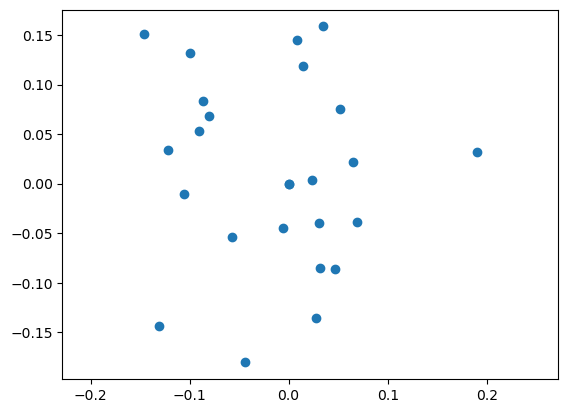

In [15]:
def init_trajectory(control_point_num):  # 生成初始轨迹
    xs, ys, rotations = resample_polyline([
        [0, 0, 0],
        [0, 0, 2 * np.pi]
    ], control_point_num).T
    return xs, ys, rotations

xs, ys, rotations = init_trajectory(  # 初始轨迹
    control_point_num=25,  # 轨迹的控制点数量
)

xs[1:-1] += np.random.randn(len(xs) - 2) * 0.1
ys[1:-1] += np.random.randn(len(ys) - 2) * 0.1

plt.scatter(xs, ys)
plt.axis('equal')
pass

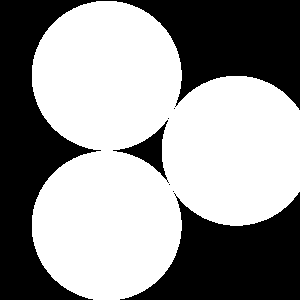

In [13]:
# 可视化墙（白色区域为墙）

from utils import test_forbidden_function

center_0 = ti.Vector([-np.cos(np.pi / 3), np.sin(np.pi / 3)]) / (3 ** 0.5)
center_1 = ti.Vector([1., 0.]) / (3 ** 0.5)
center_2 = ti.Vector([-np.cos(-np.pi / 3), np.sin(-np.pi / 3)]) / (3 ** 0.5)
r = 0.5
@ti.func
def is_forbidden(x1, y1, x2, y2):  # 指定哪里是墙
    v = ti.Vector([x2, y2])
    return (v - center_0).norm() < r or (v - center_1).norm() < r or (v - center_2).norm() < r  # 等边三个圆内是墙

image = test_forbidden_function(
    is_forbidden,
    -1, 1, -1, 1, [300, 300],
    # wall_normal=[0, 0.05]
)
Image.fromarray(np.array(image.T[::-1] * 255, dtype=np.uint8))

In [ ]:
xs, ys, rotations = np.load('../trajectory/能让等边三个圆旋转一周的房间_r0.35_3/sofa_500.npy')

In [ ]:
# delta_x = xs[0] - (xs[1] + xs[-2]) / 2
# delta_y = ys[0] - (ys[1] + ys[-2]) / 2
# xs[1:-1] += delta_x
# ys[1:-1] += delta_y

(-0.08065190481979656,
 0.0818543164954152,
 -0.08450812794541696,
 0.07886802904737537)

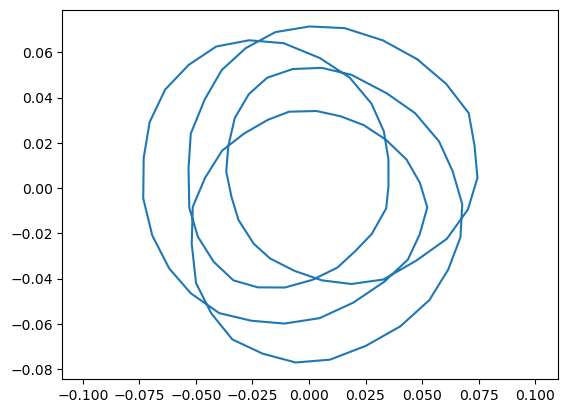

In [25]:
plt.plot(xs, ys)
plt.axis('equal')

Initial survivors: 5.343990325927734
iter 500 / 10000, maximal_area=5.34415340423584
iter 1000 / 10000, maximal_area=5.344385147094727
iter 1500 / 10000, maximal_area=5.344573974609375
iter 2000 / 10000, maximal_area=5.344754219055176
iter 2500 / 10000, maximal_area=5.344900131225586
iter 3000 / 10000, maximal_area=5.344977378845215
iter 3500 / 10000, maximal_area=5.345071792602539
iter 4000 / 10000, maximal_area=5.345123291015625
iter 4500 / 10000, maximal_area=5.345191955566406
iter 5000 / 10000, maximal_area=5.34525203704834
iter 5500 / 10000, maximal_area=5.345269203186035
iter 6000 / 10000, maximal_area=5.345355033874512
iter 6500 / 10000, maximal_area=5.345406532287598
iter 7000 / 10000, maximal_area=5.345415115356445
iter 7500 / 10000, maximal_area=5.345432281494141
iter 8000 / 10000, maximal_area=5.345449447631836
iter 8500 / 10000, maximal_area=5.3455095291137695
iter 9000 / 10000, maximal_area=5.3455095291137695
iter 9500 / 10000, maximal_area=5.3455352783203125
iter 10000 / 

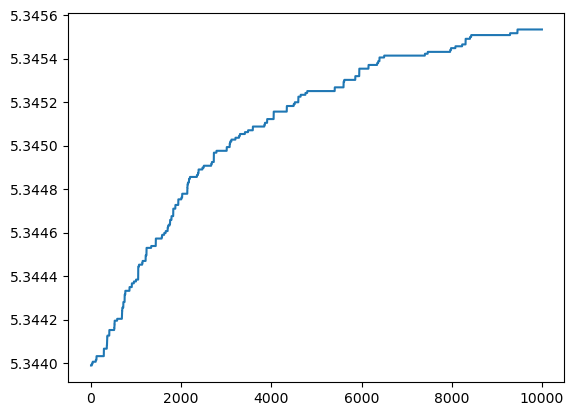

In [23]:
sofa_w, sofa_h = 3, 3   # 求解域的尺寸

best_score, xs, ys, rotations, sofa, maximal_area_record = run_optimization(
    is_forbidden,
    # xs,  # 上采样使得轨迹分辨率翻倍时注释掉这三行
    # ys,
    # rotations,
    initial_xs=zoom(xs, zoom=2, order=1),  # 保持轨迹分辨率时注释掉这三行
    initial_ys=zoom(ys, zoom=2, order=1),
    initial_rotations=zoom(rotations, zoom=2, order=1),
    sofa_w=sofa_w,
    sofa_h=sofa_h,
    mutation_sigma_pos = 0.002,  # 变异率 0.002
    mutation_sigma_rotation = 0,  # 变异率 0.004
    iterations = 10000,  # 200000
    trajectory_upsampling=41,  # 41 101
    resolution=1024,  # 1024 2000
    print_every=500,  # 1000
    save_image_every=100,
    save_image_path='../images/能让等边三个圆旋转一周的房间_r0.5_0/sofa_',
    save_image_start_id=200,
    save_trajectory_path='../trajectory/能让等边三个圆旋转一周的房间_r0.5_0/sofa_',
    boundary_conditions='periodic'
)
print(f"Estimated maximal sofa area (by sampling): {best_score:.5f}")
# save mask image as PNG if pillow is available

img = (sofa * 255).astype(np.uint8)
im = Image.fromarray(img.T[::-1])
im.save('../sofa_survivors.png')
plt.plot(maximal_area_record)

In [24]:
area = sofa_w * sofa_h - maximal_area_record[-1]
area_compare = np.pi * ((1 / (3 ** 0.5) + r) ** 2 - max(0, 1 / (3 ** 0.5) - r) ** 2)
f'{area} / {area_compare} = {area / area_compare}'

'3.6544647216796875 / 3.6275987284684352 = 1.0074059991807844'